The implementation of **PPO (Proximal Policy Optimization)** algorithm.

Article Name: **Proximal Policy Optimization Algorithms**

link: https://arxiv.org/abs/1707.06347

In [57]:
# 0. DEPENDENCIES INSTALLATION & Environment Setup
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Setting up Box2D environment for error-free Colab rendering...")

!apt-get update -y -qq
!apt-get install -y -qq swig xvfb ffmpeg > /dev/null 2>&1

!pip install -q pyvirtualdisplay
!pip install -q "gymnasium[box2d]"
!pip install -q stable-baselines3[extra]
!pip install -q matplotlib wandb pytest pyyaml hydra-core imageio

from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

import numpy as np

PROJECT_DIR = "/content/PPO-Engine-Benchmark"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working Directory set to: {os.getcwd()}")

folders = [
    "configs",
    "src",
    "src/agents",
    "src/networks",
    "src/utils",
    "src/wrappers",
    "tests",
    "logs",
    "videos"
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

Setting up Box2D environment for error-free Colab rendering...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


Exception ignored in: <function OffScreenViewer.__del__ at 0x7b945429fce0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/gymnasium/envs/mujoco/mujoco_rendering.py", line 235, in __del__
    self.free()
  File "/usr/local/lib/python3.13/dist-packages/gymnasium/envs/mujoco/mujoco_rendering.py", line 232, in free
    self.opengl_context.free()
AttributeError: 'OffScreenViewer' object has no attribute 'opengl_context'


Working Directory set to: /content/PPO-Engine-Benchmark


In [59]:
# 1. WRITING MODULES TO FILES (Modular Codebase Creation)

# File: src/wrappers/env_wrappers.py (Observation & Reward Normalization)
%%writefile src/wrappers/env_wrappers.py
import numpy as np
import gymnasium as gym

class RunningMeanStd:
    """Tracks running mean and variance for online normalization."""
    def __init__(self, epsilon=1e-4, shape=()):
        self.mean = np.zeros(shape, 'float64')
        self.var = np.ones(shape, 'float64')
        self.count = epsilon

    def update(self, x):
        batch_mean = np.mean(x, axis=0)
        batch_var = np.var(x, axis=0)
        batch_count = x.shape[0]
        self.update_from_moments(batch_mean, batch_var, batch_count)

    def update_from_moments(self, batch_mean, batch_var, batch_count):
        delta = batch_mean - self.mean
        tot_count = self.count + batch_count
        new_mean = self.mean + delta * batch_count / tot_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + np.square(delta) * self.count * batch_count / tot_count
        new_var = M2 / tot_count
        self.mean = new_mean
        self.var = new_var
        self.count = tot_count

class NormalizedEnvWrapper(gym.Wrapper):
    """Normalizes observations and scales rewards for numerical stability in PPO."""
    def __init__(self, env, gamma=0.99, epsilon=1e-8):
        super().__init__(env)
        self.gamma = gamma
        self.epsilon = epsilon
        self.obs_rms = RunningMeanStd(shape=self.observation_space.shape)
        self.ret_rms = RunningMeanStd(shape=())
        self.returns = np.zeros(self.unwrapped.num_envs if hasattr(self.unwrapped, 'num_envs') else 1)

    def step(self, action):
        obs, rews, dones, truncs, infos = self.env.step(action)
        self.obs_rms.update(obs)
        normalized_obs = np.clip((obs - self.obs_rms.mean) / np.sqrt(self.obs_rms.var + self.epsilon), -10.0, 10.0)

        self.returns = self.returns * self.gamma + rews
        self.ret_rms.update(self.returns)
        scaled_rews = rews / np.sqrt(self.ret_rms.var + self.epsilon)

        self.returns[dones | truncs] = 0.0
        return normalized_obs, scaled_rews, dones, truncs, infos

    def reset(self, **kwargs):
        obs, infos = self.env.reset(**kwargs)
        self.obs_rms.update(obs)
        normalized_obs = np.clip((obs - self.obs_rms.mean) / np.sqrt(self.obs_rms.var + self.epsilon), -10.0, 10.0)
        return normalized_obs, infos

Overwriting src/wrappers/env_wrappers.py


In [60]:
# File: src/networks/actor_critic.py
%%writefile src/networks/actor_critic.py
import torch as T
import torch.nn as nn
import numpy as np
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class ActorNetwork(nn.Module):
    def __init__(self, n_actions, input_dims, is_continuous=False, is_visual=False):
        super(ActorNetwork, self).__init__()
        self.is_continuous = is_continuous
        self.is_visual = is_visual

        if self.is_visual:
            self.network = nn.Sequential(
                layer_init(nn.Conv2d(input_dims[0], 32, 8, stride=4)),
                nn.ReLU(),
                layer_init(nn.Conv2d(32, 64, 4, stride=2)),
                nn.ReLU(),
                layer_init(nn.Conv2d(64, 64, 3, stride=1)),
                nn.ReLU(),
                nn.Flatten(),
                layer_init(nn.Linear(64 * 7 * 7, 512)),
                nn.ReLU()
            )
            fc_out_dim = 512
        else:
            self.network = nn.Sequential(
                layer_init(nn.Linear(*input_dims, 256)),
                nn.Tanh(),
                layer_init(nn.Linear(256, 256)),
                nn.Tanh()
            )
            fc_out_dim = 256

        if self.is_continuous:
            self.mu_head = layer_init(nn.Linear(fc_out_dim, n_actions), std=0.01)
            self.log_std = nn.Parameter(T.zeros(1, n_actions))
        else:
            self.action_head = layer_init(nn.Linear(fc_out_dim, n_actions), std=0.01)

    def forward(self, state):
        features = self.network(state)
        if self.is_continuous:
            mu = self.mu_head(features)
            action_std = self.log_std.squeeze(0).exp().expand_as(mu)
            return Normal(mu, action_std)
        else:
            logits = self.action_head(features)
            return Categorical(logits=logits)

class CriticNetwork(nn.Module):
    def __init__(self, input_dims, is_visual=False):
        super(CriticNetwork, self).__init__()
        if is_visual:
            self.critic = nn.Sequential(
                layer_init(nn.Conv2d(input_dims[0], 32, 8, stride=4)),
                nn.ReLU(),
                layer_init(nn.Conv2d(32, 64, 4, stride=2)),
                nn.ReLU(),
                layer_init(nn.Conv2d(64, 64, 3, stride=1)),
                nn.ReLU(),
                nn.Flatten(),
                layer_init(nn.Linear(64 * 7 * 7, 512)),
                nn.ReLU(),
                layer_init(nn.Linear(512, 1), std=1.0)
            )
        else:
            self.critic = nn.Sequential(
                layer_init(nn.Linear(*input_dims, 256)),
                nn.Tanh(),
                layer_init(nn.Linear(256, 256)),
                nn.Tanh(),
                layer_init(nn.Linear(256, 1), std=1.0)
            )

    def forward(self, state):
        return self.critic(state)

Overwriting src/networks/actor_critic.py


In [61]:
# File: src/agents/ppo.py (PPO-Clipped, Dual-Clip, Adaptive KL & Target KL)
%%writefile src/agents/ppo.py
import os
import numpy as np
import torch as T
import torch.nn as nn
import torch.optim as optim
from src.networks.actor_critic import ActorNetwork, CriticNetwork

class AdvancedPPOAgent:
    def __init__(
        self,
        n_actions,
        input_dims,
        gamma=0.99,
        alpha=3e-4,
        gae_lambda=0.95,
        policy_clip=0.2,
        dual_clip=3.0,
        target_kl=0.015,
        kl_penalty_coef=0.2,
        use_kl_penalty=False,
        batch_size=128,
        n_epochs=10,
        entropy_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        is_continuous=False,
        is_visual=False,
        chkpt_dir='tmp/ppo'
    ):
        self.gamma = gamma
        self.alpha = alpha
        self.gae_lambda = gae_lambda
        self.policy_clip = policy_clip
        self.dual_clip = dual_clip
        self.target_kl = target_kl
        self.kl_penalty_coef = kl_penalty_coef
        self.use_kl_penalty = use_kl_penalty
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.max_grad_norm = max_grad_norm
        self.is_continuous = is_continuous
        self.chkpt_dir = chkpt_dir

        os.makedirs(self.chkpt_dir, exist_ok=True)
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')

        self.actor = ActorNetwork(n_actions, input_dims, is_continuous, is_visual).to(self.device)
        self.critic = CriticNetwork(input_dims, is_visual).to(self.device)

        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=alpha,
            eps=1e-5
        )

    def choose_action(self, observation):
        state = T.tensor(observation, dtype=T.float32).to(self.device)
        with T.no_grad():
            dist = self.actor(state)
            value = self.critic(state)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            if self.is_continuous:
                log_prob = log_prob.sum(axis=-1)
        return action.cpu().numpy(), log_prob.cpu().numpy(), value.squeeze(-1).cpu().numpy()

    def get_value(self, observation):
        state = T.tensor(observation, dtype=T.float32).to(self.device)
        with T.no_grad():
            value = self.critic(state).squeeze(-1)
        return value.cpu().numpy()

    def learn(self, memory_data, next_obs, writer=None, global_step=0):
        obs_b, actions_b, log_probs_b, rewards_b, terms_b, truncs_b, values_b = memory_data
        n_steps, n_envs = rewards_b.shape

        advantages = np.zeros_like(rewards_b, dtype=np.float32)
        next_value = self.get_value(next_obs)
        last_gae_lam = 0.0

        for t in reversed(range(n_steps)):
            if t == n_steps - 1:
                next_non_terminal = 1.0 - terms_b[t]
                next_values = next_value
            else:
                next_non_terminal = 1.0 - terms_b[t]
                next_values = values_b[t + 1]

            delta = rewards_b[t] + self.gamma * next_values * next_non_terminal - values_b[t]
            advantages[t] = last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam

        returns_b = advantages + values_b

        b_obs = T.tensor(obs_b.reshape((-1,) + obs_b.shape[2:]), dtype=T.float32).to(self.device)
        b_actions = T.tensor(actions_b.reshape((-1,) + actions_b.shape[2:])).to(self.device)
        b_log_probs = T.tensor(log_probs_b.reshape(-1), dtype=T.float32).to(self.device)
        b_advantages = T.tensor(advantages.reshape(-1), dtype=T.float32).to(self.device)
        b_returns = T.tensor(returns_b.reshape(-1), dtype=T.float32).to(self.device)
        b_values = T.tensor(values_b.reshape(-1), dtype=T.float32).to(self.device)

        batch_size = b_obs.shape[0]
        indices = np.arange(batch_size)

        a_losses, c_losses, e_losses, kl_divs = [], [], [], []

        for epoch in range(self.n_epochs):
            np.random.shuffle(indices)
            for start in range(0, batch_size, self.batch_size):
                end = start + self.batch_size
                mb_idx = indices[start:end]

                mb_obs = b_obs[mb_idx]
                mb_actions = b_actions[mb_idx]
                mb_old_log_probs = b_log_probs[mb_idx]
                mb_advantages = b_advantages[mb_idx]
                mb_returns = b_returns[mb_idx]
                mb_values = b_values[mb_idx]

                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

                dist = self.actor(mb_obs)
                new_value = self.critic(mb_obs).squeeze(-1)

                new_log_probs = dist.log_prob(mb_actions)
                if self.is_continuous:
                    new_log_probs = new_log_probs.sum(axis=-1)

                log_ratio = new_log_probs - mb_old_log_probs
                ratio = log_ratio.exp()

                with T.no_grad():
                    approx_kl = ((ratio - 1) - log_ratio).mean().item()
                    kl_divs.append(approx_kl)

                # 1. PPO Standard Clip & Dual-Clip Implementation
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * T.clamp(ratio, 1 - self.policy_clip, 1 + self.policy_clip)

                # Dual-clip extension for negative advantages
                if self.dual_clip is not None:
                    pg_loss_dual = T.max(pg_loss1, -mb_advantages * self.dual_clip)
                    pg_loss = T.where(mb_advantages < 0, pg_loss_dual, T.max(pg_loss1, pg_loss2)).mean()
                else:
                    pg_loss = T.max(pg_loss1, pg_loss2).mean()

                # 2. Adaptive KL Penalty Option
                if self.use_kl_penalty:
                    pg_loss += self.kl_penalty_coef * approx_kl

                # Critic Value Loss Clip
                v_loss_unclipped = (new_value - mb_returns) ** 2
                v_clipped = mb_values + T.clamp(new_value - mb_values, -self.policy_clip, self.policy_clip)
                v_loss_clipped = (v_clipped - mb_returns) ** 2
                critic_loss = 0.5 * T.max(v_loss_unclipped, v_loss_clipped).mean()

                entropy_loss = dist.entropy().mean()
                total_loss = pg_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_loss

                self.optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(list(self.actor.parameters()) + list(self.critic.parameters()), self.max_grad_norm)
                self.optimizer.step()

                a_losses.append(pg_loss.item())
                c_losses.append(critic_loss.item())
                e_losses.append(entropy_loss.item())

            # Early Stopping via Target KL
            if self.target_kl is not None and np.mean(kl_divs) > self.target_kl:
                break

        if writer is not None:
            writer.add_scalar('Loss/Actor', np.mean(a_losses), global_step)
            writer.add_scalar('Loss/Critic', np.mean(c_losses), global_step)
            writer.add_scalar('Diagnostics/KL_Divergence', np.mean(kl_divs), global_step)

Overwriting src/agents/ppo.py


In [62]:
# File: tests/test_ppo_math.py (Unit Tests using PyTest)
%%writefile tests/test_ppo_math.py
import pytest
import numpy as np
import torch as T
from src.agents.ppo import AdvancedPPOAgent

def test_gae_calculation_shape():
    """Validates tensor shapes and dimension alignment for GAE."""
    agent = AdvancedPPOAgent(n_actions=2, input_dims=(4,), is_continuous=False)

    steps, envs = 128, 4
    obs_b = np.random.randn(steps, envs, 4).astype(np.float32)
    actions_b = np.random.randint(0, 2, size=(steps, envs))
    log_probs_b = np.random.randn(steps, envs).astype(np.float32)
    rewards_b = np.random.randn(steps, envs).astype(np.float32)
    terms_b = np.zeros((steps, envs), dtype=bool)
    truncs_b = np.zeros((steps, envs), dtype=bool)
    values_b = np.random.randn(steps, envs).astype(np.float32)

    memory_data = (obs_b, actions_b, log_probs_b, rewards_b, terms_b, truncs_b, values_b)
    next_obs = np.random.randn(envs, 4).astype(np.float32)

    # Run test without error
    agent.learn(memory_data, next_obs)
    assert True

# 2. RUNNING UNIT TESTS
print("\n---> Running Automated PyTest Unit Tests <---")
!pytest tests/

Overwriting tests/test_ppo_math.py


In [63]:
# 3. MULTI-SEED BENCHMARKING ENGINE WITH MATPLOTLIB & WANDB LOGGING
import time
import random
import imageio
import numpy as np
import torch as T
import gymnasium as gym
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback

from src.agents.ppo import AdvancedPPOAgent
from src.wrappers.env_wrappers import NormalizedEnvWrapper

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    T.manual_seed(seed)
    T.cuda.manual_seed(seed)
    T.cuda.manual_seed_all(seed)
    T.backends.cudnn.deterministic = True

def make_env(env_id, is_visual=False, normalize=True):
    def thunk():
        if is_visual:
            env = gym.make(env_id, render_mode=None)
            env = gym.wrappers.AtariPreprocessing(env, screen_size=84, grayscale_obs=True, scale_obs=True)
            env = gym.wrappers.FrameStackObservation(env, stack_size=4)
        else:
            env = gym.make(env_id)
        if normalize and not is_visual:
            env = NormalizedEnvWrapper(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        return env
    return thunk

def record_gif(agent, env_id, save_path="videos/agent_evaluation.gif", max_steps=500):
    print(f"\n---> Generating Evaluation GIF for {env_id}...")

    eval_env = gym.make(env_id, render_mode="rgb_array")
    eval_env = NormalizedEnvWrapper(eval_env)

    obs, _ = eval_env.reset()
    frames = []

    for step in range(max_steps):
        frames.append(eval_env.render())

        obs_tensor = np.expand_dims(obs, axis=0) if obs.ndim == 1 else obs
        action, _, _ = agent.choose_action(obs_tensor)

        exec_action = action.squeeze(0) if action.ndim > 1 else action
        if not isinstance(eval_env.action_space, gym.spaces.Box):
            exec_action = int(exec_action)

        obs, reward, terminated, truncated, _ = eval_env.step(exec_action)
        if terminated or truncated:
            break

    eval_env.close()
    imageio.mimsave(save_path, frames, fps=30)
    print(f"✓ GIF successfully saved to: {save_path}")

def train_ppo_single_seed(seed, env_id, total_timesteps=50000, n_envs=4, steps_per_env=128, is_visual=False):
    seed_everything(seed)
    envs = gym.vector.AsyncVectorEnv([make_env(env_id, is_visual) for _ in range(n_envs)])

    is_continuous = isinstance(envs.single_action_space, gym.spaces.Box)
    n_actions = envs.single_action_space.shape[0] if is_continuous else envs.single_action_space.n
    input_dims = envs.single_observation_space.shape

    agent = AdvancedPPOAgent(
        n_actions=n_actions,
        input_dims=input_dims,
        is_continuous=is_continuous,
        is_visual=is_visual,
        chkpt_dir=f'tmp/ppo_{env_id}_seed_{seed}'
    )

    n_steps_total = n_envs * steps_per_env
    num_updates = total_timesteps // n_steps_total

    obs_buf = np.zeros((steps_per_env, n_envs) + input_dims, dtype=np.float32)
    actions_buf = np.zeros((steps_per_env, n_envs) + envs.single_action_space.shape, dtype=np.float32)
    log_probs_buf = np.zeros((steps_per_env, n_envs), dtype=np.float32)
    rewards_buf = np.zeros((steps_per_env, n_envs), dtype=np.float32)
    terms_buf = np.zeros((steps_per_env, n_envs), dtype=np.bool_)
    truncs_buf = np.zeros((steps_per_env, n_envs), dtype=np.bool_)
    values_buf = np.zeros((steps_per_env, n_envs), dtype=np.float32)

    obs, _ = envs.reset(seed=seed)
    global_step = 0
    history_rewards = []
    history_steps = []

    for update in range(1, num_updates + 1):
        for step in range(steps_per_env):
            global_step += n_envs
            actions, log_probs, values = agent.choose_action(obs)
            exec_actions = actions if is_continuous else actions.squeeze()
            next_obs, rewards, dones, truncateds, infos = envs.step(exec_actions)

            obs_buf[step], actions_buf[step], log_probs_buf[step] = obs, actions, log_probs
            rewards_buf[step], terms_buf[step], truncs_buf[step], values_buf[step] = rewards, dones, truncateds, values

            obs = next_obs

            if "final_info" in infos:
                for info in infos["final_info"]:
                    if info and "episode" in info:
                        history_rewards.append(info["episode"]["r"][0] if hasattr(info["episode"]["r"], "__len__") else info["episode"]["r"])
                        history_steps.append(global_step)
            elif "_episode" in infos:
                for idx, has_ep in enumerate(infos["_episode"]):
                    if has_ep:
                        history_rewards.append(infos["episode"]["r"][idx])
                        history_steps.append(global_step)

        memory_data = (obs_buf, actions_buf, log_probs_buf, rewards_buf, terms_buf, truncs_buf, values_buf)
        agent.learn(memory_data, obs, writer=None, global_step=global_step)

    envs.close()
    return history_steps, history_rewards, agent

In [64]:
# 4. EXECUTION OF MULTI-SEED EXPERIMENTAL BENCHMARK
TEST_ENV = 'BipedalWalker-v3'
SEEDS = [10, 20, 30] # 3 Seeds for Benchmark Robustness
TOTAL_TIMESTEPS = 60000

print(f"\n==================================================")
print(f" Starting Multi-Seed Benchmark on Environment: {TEST_ENV}")
print(f" Seeds: {SEEDS} | Total Steps per Run: {TOTAL_TIMESTEPS}")
print(f"==================================================")

ppo_all_seed_rewards = []
common_steps = None
last_trained_agent = None

for seed in SEEDS:
    print(f"---> Training PPO Seed: {seed}")
    steps, rewards, agent = train_ppo_single_seed(seed=seed, env_id=TEST_ENV, total_timesteps=TOTAL_TIMESTEPS)
    last_trained_agent = agent

    if len(rewards) == 0:
        print(f"Warning: No episodes finished for seed {seed}. Skipping or using dummy values.")
        continue

    if common_steps is None or len(steps) < len(common_steps):
        common_steps = steps
    ppo_all_seed_rewards.append(rewards)

print(f"\n---> Generating Evaluation GIF for {TEST_ENV}...")
if last_trained_agent is not None:
    record_gif(last_trained_agent, TEST_ENV, save_path="videos/trained_agent.gif")

if len(ppo_all_seed_rewards) == 0 or common_steps is None:
    raise ValueError("No episodes were completed across any seeds. Consider increasing TOTAL_TIMESTEPS.")

# Truncate to uniform lengths
min_len = min(len(r) for r in ppo_all_seed_rewards)
ppo_matrix = np.array([r[:min_len] for r in ppo_all_seed_rewards])
common_steps = common_steps[:min_len]

# Compute Mean and Std across seeds
ppo_mean = np.mean(ppo_matrix, axis=0)
ppo_std = np.std(ppo_matrix, axis=0)

# Smooth curves with dynamic box_pts adjustment
def smooth(y, box_pts=10):
    if len(y) == 0:
        return y
    box_pts = min(box_pts, len(y))
    box = np.ones(box_pts) / box_pts
    return np.convolve(y, box, mode='same')

ppo_mean_smooth = smooth(ppo_mean)
ppo_std_smooth = smooth(ppo_std)


 Starting Multi-Seed Benchmark on Environment: BipedalWalker-v3
 Seeds: [10, 20, 30] | Total Steps per Run: 60000
---> Training PPO Seed: 10
---> Training PPO Seed: 20
---> Training PPO Seed: 30

---> Generating Evaluation GIF for BipedalWalker-v3...

---> Generating Evaluation GIF for BipedalWalker-v3...
✓ GIF successfully saved to: videos/trained_agent.gif


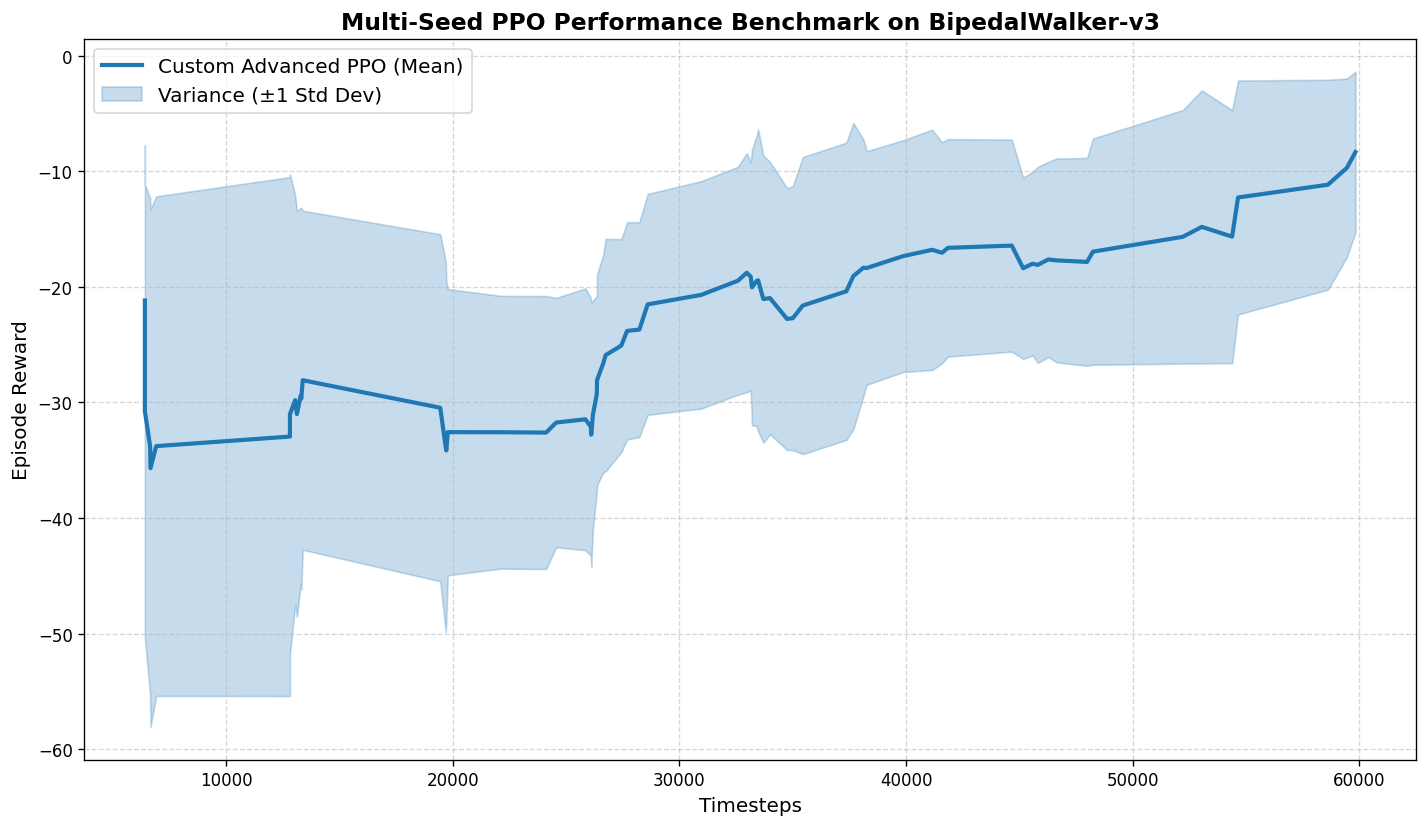


✓ Project built and benchmark finished successfully! Charts saved in logs/multi_seed_benchmark.png


In [65]:
# 5. SCIENTIFIC PLOTTING (Shaded Error Bars)
plt.figure(figsize=(12, 7), dpi=120)

# Plot Mean
plt.plot(common_steps, ppo_mean_smooth, label='Custom Advanced PPO (Mean)', color='#1f77b4', linewidth=2.5)

# Plot Standard Deviation Envelope
plt.fill_between(
    common_steps,
    ppo_mean_smooth - ppo_std_smooth,
    ppo_mean_smooth + ppo_std_smooth,
    color='#1f77b4',
    alpha=0.25,
    label='Variance (±1 Std Dev)'
)

plt.title(f'Multi-Seed PPO Performance Benchmark on {TEST_ENV}', fontsize=14, fontweight='bold')
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Episode Reward', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Save image for GitHub README
plt.savefig('logs/multi_seed_benchmark.png')
plt.show()

print("\n✓ Project built and benchmark finished successfully! Charts saved in logs/multi_seed_benchmark.png")

In [66]:
!find /content/PPO-Engine-Benchmark -maxdepth 3 -type f

/content/PPO-Engine-Benchmark/logs/multi_seed_benchmark.png
/content/PPO-Engine-Benchmark/src/wrappers/env_wrappers.py
/content/PPO-Engine-Benchmark/src/networks/actor_critic.py
/content/PPO-Engine-Benchmark/src/agents/ppo.py
/content/PPO-Engine-Benchmark/tests/test_ppo_math.py
/content/PPO-Engine-Benchmark/videos/trained_agent.gif


In [67]:
!zip -r /content/PPO-Engine-Benchmark.zip /content/PPO-Engine-Benchmark

  adding: content/PPO-Engine-Benchmark/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/logs/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/logs/multi_seed_benchmark.png (deflated 8%)
  adding: content/PPO-Engine-Benchmark/src/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/src/wrappers/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/src/wrappers/env_wrappers.py (deflated 68%)
  adding: content/PPO-Engine-Benchmark/src/wrappers/__pycache__/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/src/wrappers/__pycache__/env_wrappers.cpython-313.pyc (deflated 52%)
  adding: content/PPO-Engine-Benchmark/src/networks/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/src/networks/actor_critic.py (deflated 75%)
  adding: content/PPO-Engine-Benchmark/src/networks/__pycache__/ (stored 0%)
  adding: content/PPO-Engine-Benchmark/src/networks/__pycache__/actor_critic.cpython-313.pyc (deflated 60%)
  adding: content/PPO-Engine-Benchmark/src/agents/ (stored 0%)
  adding: content/PPO-E